In [19]:
import numpy as np
npzfile_stops = np.load("../Data/daily_stops.npz", allow_pickle=True)
stops_list = npzfile_stops['stops_list']  
nr_vehicles = npzfile_stops['nr_vehicles']  
weekday = npzfile_stops['weekday']  
capacities_list = npzfile_stops['capacities_list']  
demands_list = npzfile_stops['demands_list']  
npzfile_route = np.load("../Data/daily_routematrix.npz", allow_pickle=True)
opmat = npzfile_route['incidence_matrices'] 
stop_wise_days = npzfile_route['stop_wise_active'] 
distance_matrix = np.load("../Data/Distancematrix.npy") 
edge_mat = np.load("../Data/edge_category.npy") 

##### Coordinate

In [ ]:
import numpy as np
import pandas as pd
from sklearn.manifold import MDS

# 讀取距離矩陣
distance_matrix = np.load('./Distancematrix.npy')

# 確認距離矩陣的結構
print("距離矩陣:")
print(distance_matrix)
print(f"矩陣形狀: {distance_matrix.shape}")

# 確保矩陣對稱並填充對角線為 0
distance_matrix = (distance_matrix + distance_matrix.T) / 2  # 對稱化
np.fill_diagonal(distance_matrix, 0)  # 對角線填 0

# 使用 MDS 計算相對座標
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
coordinates = mds.fit_transform(distance_matrix)

# 平移第 0 點到 (0, 0)
coordinates -= coordinates[0]

# 將座標存入 DataFrame
df = pd.DataFrame(coordinates, columns=['X', 'Y'])
df.index.name = 'Point'

# 將座標輸出為 CSV
output_path = './coordinates.csv'
df.to_csv(output_path)

print(f"座標已儲存到 {output_path}")


##### Target distance and route

In [40]:
import numpy as np
import csv
import os
import time
from Util import VRPsolutiontoList

npzfile_route = np.load("../Data/daily_routematrix.npz", allow_pickle=True)
trgt = npzfile_route['incidence_matrices'] 
distance_matrix = np.load("../Data/Distancematrix.npy")

# 輸出 CSV 文件名稱
output_csv = "../Output/baseline/trgt_routes_0119.csv"

# 如果文件已存在，刪除
if os.path.exists(output_csv):
    os.remove(output_csv)

# 打開 CSV 文件進行寫入
with open(output_csv, mode='w', newline='') as file:
    writer = csv.writer(file)
    
    # 寫入表頭
    writer.writerow(["Day", "Vehicle", "Route", "Distance"])

    for i in range(len(trgt)):
        if i + 1 == 89:  # 排除第 89 天
            continue
        try:
            routes = VRPsolutiontoList(trgt[i])
            print(f"Day {i + 1}:")
            for car in range(len(routes)):
                route = routes[car]
                route_with_arrows = '->'.join(map(str, route))

                # 計算路徑總距離
                distance = sum(distance_matrix[route[j], route[j + 1]] for j in range(len(route) - 1))

                # 寫入 CSV
                writer.writerow([i + 1, car + 1, route_with_arrows, distance])

                # 輸出到控制台
                print(f"  Vehicle {car + 1}: {route_with_arrows}, Distance: {distance}")

        except Exception as e:
            print(f"Day {i + 1} 發生錯誤: {e}")
            continue

print(f"所有結果已保存至 {output_csv}")


Day 1:
  Vehicle 1: 0->35->7->0, Distance: 22.865942388566857
  Vehicle 2: 0->57->50->54->9->58->7->0, Distance: 182.11361313298414
  Vehicle 3: 0->62->13->51->52->0, Distance: 87.17700879897025
  Vehicle 4: 0->64->56->68->0, Distance: 24.1195021998477
  Vehicle 5: 0->66->61->55->16->71->67->7->0, Distance: 245.47276223978534
  Vehicle 6: 0->70->53->15->63->69->60->0, Distance: 60.26957809546674
Day 2:
  Vehicle 1: 0->20->0, Distance: 19.50128822611338
  Vehicle 2: 0->21->17->7->0, Distance: 69.32519448631473
  Vehicle 3: 0->25->0, Distance: 15.574573709138354
  Vehicle 4: 0->31->24->19->7->0, Distance: 22.805260377143345
  Vehicle 5: 0->57->50->54->28->58->0, Distance: 186.00430011870742
  Vehicle 6: 0->59->61->55->16->71->67->0, Distance: 239.8209069343838
  Vehicle 7: 0->62->13->52->51->0, Distance: 88.41503968717393
  Vehicle 8: 0->64->56->68->0, Distance: 24.1195021998477
  Vehicle 9: 0->70->53->66->63->15->60->69->0, Distance: 63.38682102734852
Day 3:
  Vehicle 1: 0->18->0, Dista

In [42]:
import pandas as pd
df = pd.read_csv("../Output/baseline/trgt_routes_0119.csv")

merged_df = df.pivot(index='Day', columns='Vehicle', values=['Route', 'Distance'])

# 重新排列欄位順序以實現交錯
columns_ordered = []
for vehicle in sorted(merged_df.columns.levels[1]):
    columns_ordered.append(("Route", vehicle))
    columns_ordered.append(("Distance", vehicle))
merged_df = merged_df[columns_ordered]

# 重命名欄位名稱
merged_df.columns = [f"Vehicle_{col[1]}_{col[0]}" for col in merged_df.columns]

# 重置索引並輸出結果
merged_df.reset_index(inplace=True)
merged_df.columns.name = None

merged_df.to_csv('../Data/trgt.csv')


In [8]:
import pandas as pd

# 讀取資料
df = pd.read_csv("../Data/trgt.csv")

# 定義測試天數
test_days = {
    7, 14, 18, 25, 26, 32, 33, 39, 40, 46, 53, 56, 63, 70,
    77, 82, 86, 88, 89, 93, 100, 107, 117, 123, 126,
    154, 160, 166, 173, 180, 187, 194, 155, 161, 167, 174, 181,
    188, 195, 149, 156, 168, 175, 182, 189, 196, 150, 162, 169,
    176, 183, 190, 197, 157, 163, 170, 177, 184, 191, 198, 158,
    164, 171, 178, 185, 192, 199, 159, 165, 172, 179, 186, 193, 200
}

# 過濾不是測試天數的資料
non_test_days = df[~df['Day'].isin(test_days)]

# 計算所有距離的總和
total_distance = non_test_days.filter(like='Distance').sum().sum()

total_distance


#day 89: 684

80650.11538934488

In [9]:
# 過濾出特定天數的資料
specific_day_data = df[df['Day'] == 7]

# 計算該天所有車輛的距離總和
total_distance_specific_day = specific_day_data.filter(like='Distance').sum().sum()

total_distance_specific_day


684.3854513621006

##### MIP distance and route

In [10]:
import pandas as pd

# 讀取資料
df = pd.read_csv("../Output/baseline/baseline_routes_1.csv")

# 定義測試天數
test_days = {
    7, 14, 18, 25, 26, 32, 33, 39, 40, 46, 53, 56, 63, 70,
    77, 82, 86, 88, 89, 93, 100, 107, 117, 123, 126,
    154, 160, 166, 173, 180, 187, 194, 155, 161, 167, 174, 181,
    188, 195, 149, 156, 168, 175, 182, 189, 196, 150, 162, 169,
    176, 183, 190, 197, 157, 163, 170, 177, 184, 191, 198, 158,
    164, 171, 178, 185, 192, 199, 159, 165, 172, 179, 186, 193, 200
}

# 過濾不是測試天數的資料
non_test_days = df[~df['Day'].isin(test_days)]

# 計算所有距離的總和
total_distance = non_test_days.filter(like='Distance').sum().sum()

total_distance

84336.496289907

In [11]:
# 過濾出特定天數的資料
specific_day_data = df[df['Day'] == 7]

# 計算該天所有車輛的距離總和
total_distance_specific_day = specific_day_data.filter(like='Distance').sum().sum()

total_distance_specific_day



0.0

##### Route visualization

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
coordinates_df = pd.read_csv('../Data/coordinates.csv')
coordinates_df.set_index('Point', inplace=True)

def visualize_routes(routes_df, coordinates_df, who="Driver"):
    # 篩選出第一天的資料
    day_1_df = routes_df[routes_df['Day'] == 1]

    plt.figure(figsize=(12, 8))

    total_distance = 0  # 初始化總距離

    for _, row in day_1_df.iterrows():
        for vehicle in range(1, 15):  # 假設最多有14輛車
            route_col = f'Vehicle_{vehicle}_Route'
            distance_col = f'Vehicle_{vehicle}_Distance'
            
            if pd.notna(row[route_col]):  # 確保該車輛有路徑
                # 累加距離
                total_distance += row[distance_col]

                # 解析路徑為點的序列
                route = row[route_col].split(' -> ')
                route_coords = coordinates_df.loc[map(int, route)]  # 獲取路徑的座標

                # 繪製路徑
                plt.plot(route_coords['X'], route_coords['Y'], marker='o', label=f'Vehicle {vehicle}')

    # 在圖上顯示總距離
    plt.title(f"Vehicle Routes for Day 1 ({who})\nTotal Distance: {total_distance:.2f}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend(loc='best', fontsize='small')
    plt.grid(True)
    plt.show()

def visualize_routes_trgt(routes_df, coordinates_df, who="Driver"):
    # 篩選出第一天的資料
    day_1_df = routes_df[routes_df['Day'] == 2]

    plt.figure(figsize=(12, 8))

    total_distance = 0  # 初始化總距離

    for _, row in day_1_df.iterrows():
        for vehicle in range(1, 15):  # 假設最多有14輛車
            route_col = f'Vehicle_{vehicle}_Route'
            distance_col = f'Vehicle_{vehicle}_Distance'
            
            if pd.notna(row[route_col]):  # 確保該車輛有路徑
                # 累加距離
                total_distance += row[distance_col]

                # 解析路徑為點的序列
                route = row[route_col].split(' -> ')
                route_coords = coordinates_df.loc[map(int, route)]  # 獲取路徑的座標

                # 繪製路徑
                plt.plot(route_coords['X'], route_coords['Y'], marker='o', label=f'Vehicle {vehicle}')

    # 在圖上顯示總距離
    plt.title(f"Vehicle Routes for Day 1 ({who})\nTotal Distance: {total_distance:.2f}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend(loc='best', fontsize='small')
    plt.grid(True)
    plt.show()


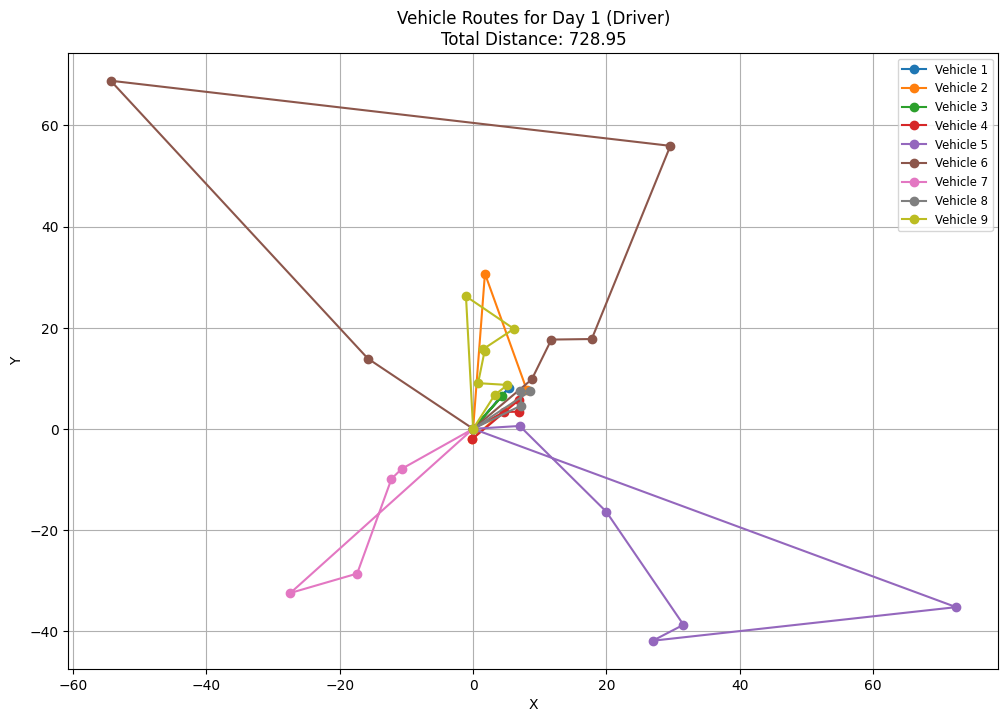

In [3]:
routes_df = pd.read_csv('../Data/trgt.csv')
visualize_routes_trgt(routes_df, coordinates_df, who='Driver')

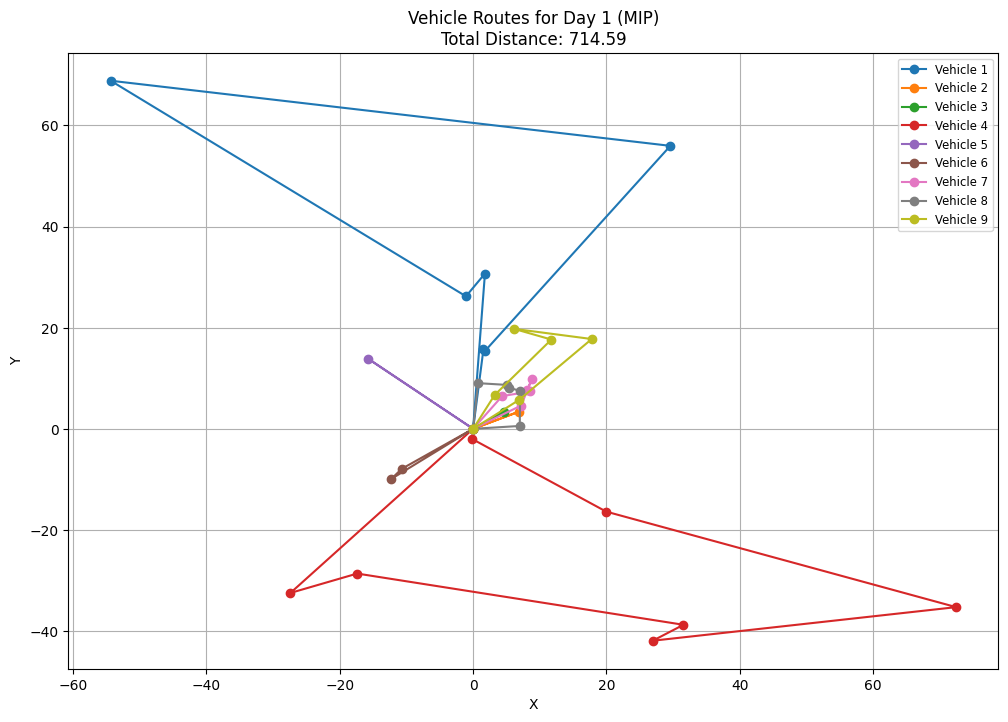

In [4]:
routes_df = pd.read_csv('../Output/baseline/baseline_routes_1.csv')
visualize_routes(routes_df, coordinates_df, who='MIP')

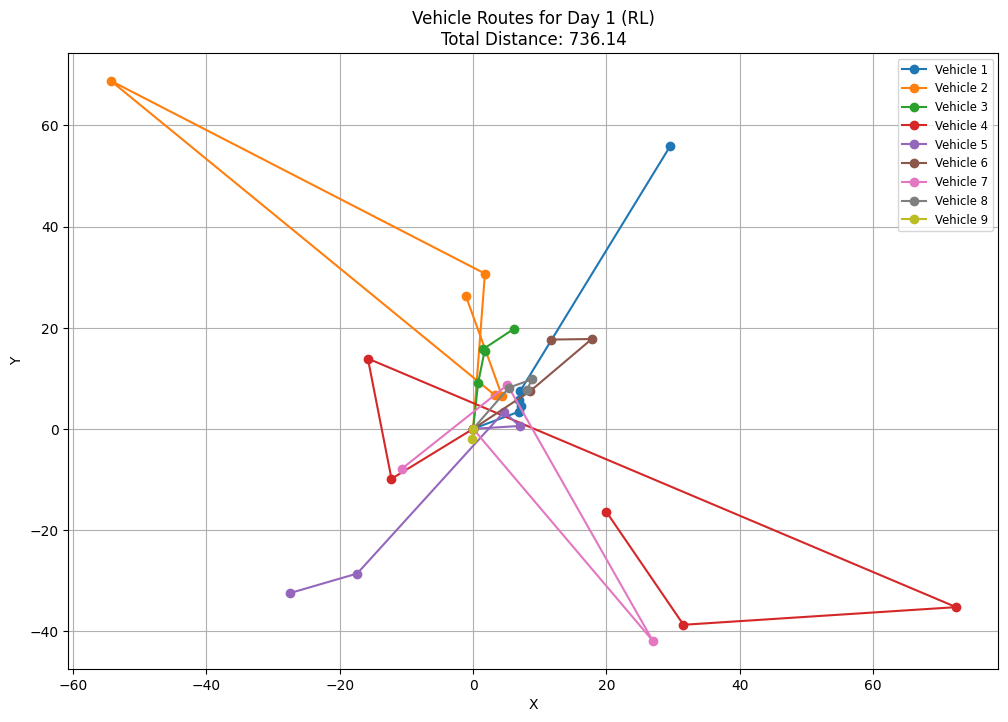

In [4]:
routes_df = pd.read_csv('../Output/training/plot.csv')
visualize_routes(routes_df, coordinates_df, who='RL')

In [11]:
import torch

# 假設你的 fulfill tensor 已經存在
fulfill = torch.tensor(
    [0., 4., 24., 0., 14., 2., 0., 15., 0., 2., 0., 0.,
     2., 14., 0., 7., 18., 34., 30., 34., 45., 30., 0., 0.,
     156., 45., 2., 0., 12., 0., 2., 0., 2., 0., 4., 26.,
     0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 2.,
     0., 0., 36., 36., 36., 36., 36., 36., 72., 36., 36., 34.,
     72., 36., 34., 54., 36., 0., 36., 36., 54., 36., 36., 72.,
     0., 0.], device='cuda:0', dtype=torch.float64
)

# 取得最大值
max_value = fulfill.max().item()  # 使用 .item() 轉換為 Python scalar
print(f"最大值: {max_value}")
normalized_fulfill = fulfill / max_value
print(normalized_fulfill)

最大值: 156.0
tensor([0.0000, 0.0256, 0.1538, 0.0000, 0.0897, 0.0128, 0.0000, 0.0962, 0.0000,
        0.0128, 0.0000, 0.0000, 0.0128, 0.0897, 0.0000, 0.0449, 0.1154, 0.2179,
        0.1923, 0.2179, 0.2885, 0.1923, 0.0000, 0.0000, 1.0000, 0.2885, 0.0128,
        0.0000, 0.0769, 0.0000, 0.0128, 0.0000, 0.0128, 0.0000, 0.0256, 0.1667,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0128, 0.0000, 0.0000, 0.2308, 0.2308, 0.2308, 0.2308,
        0.2308, 0.2308, 0.4615, 0.2308, 0.2308, 0.2179, 0.4615, 0.2308, 0.2179,
        0.3462, 0.2308, 0.0000, 0.2308, 0.2308, 0.3462, 0.2308, 0.2308, 0.4615,
        0.0000, 0.0000], device='cuda:0', dtype=torch.float64)


In [12]:
tensor_values = torch.tensor([
    0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000, 22.3686,
    0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.9447,
    38.1571, 31.4940, 25.6478, 13.0255,  0.0000, 25.5005, 18.6157,  0.0000,
    53.7170, 23.7904,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
    0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
    0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
    0.0000,  0.0000,  0.0000,  0.0000,  0.0000, 49.2429,  0.0000,  0.0000,
    0.0000, 50.1925,  0.0000,  0.0000, 40.8247,  0.0000,  0.0000,  0.0000,
    19.3928,  0.0000, 38.6344, 36.7204,  0.0000, 26.4208, 11.3170, 67.2608,
    0.0000,  0.0000
], device='cuda:0')

max_value = torch.max(tensor_values).item()
max_index = torch.argmax(tensor_values).item()
print(f"Max Q-value: {max_value}, Action: {max_index}")


Max Q-value: 67.26080322265625, Action: 71


##### Read csv (training)

In [79]:
df = pd.read_csv('../Output/training/500epochs_nor.csv')
max_epoch_row = df[df['Epoch'] == df['Epoch'].max()]
max_epoch_row

,Epoch,Day,AD,SD,Vehicle_1_Route,Vehicle_1_Distance,Vehicle_2_Route,Vehicle_2_Distance,Vehicle_3_Route,Vehicle_3_Distance,...,Vehicle_10_Route,Vehicle_10_Distance,Vehicle_11_Route,Vehicle_11_Distance,Vehicle_12_Route,Vehicle_12_Distance,Vehicle_13_Route,Vehicle_13_Distance,Vehicle_14_Route,Vehicle_14_Distance
49403,390,1,9,26,0 -> 7 -> 13 -> 15 -> 16 -> 17 -> 19 -> 20 -> ...,1064.838740,0 -> 66 -> 0,18.118547,0 -> 0,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49404,390,2,10,21,0 -> 2 -> 7 -> 16 -> 17 -> 18 -> 19 -> 21 -> 2...,940.473119,0 -> 0,0.000000,0 -> 0,0.000000,...,0 -> 0,0.000000,0 -> 70 -> 0,14.862451,0 -> 0,0.0,0 -> 0,0.0,NaN,NaN
49405,390,3,12,27,0 -> 1 -> 69 -> 16 -> 17 -> 18 -> 19 -> 20 -> ...,1042.976651,0 -> 7 -> 0,4.034626,0 -> 0,0.000000,...,0 -> 0,0.000000,0 -> 0,0.000000,0 -> 0,0.0,NaN,NaN,NaN,NaN
49406,390,4,10,26,0 -> 2 -> 10 -> 13 -> 15 -> 17 -> 18 -> 19 -> ...,1057.547371,0 -> 0,0.000000,0 -> 0,0.000000,...,0 -> 68 -> 0,22.509416,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49407,390,5,10,31,0 -> 2 -> 3 -> 13 -> 15 -> 17 -> 18 -> 19 -> 2...,1171.252731,0 -> 67 -> 0,26.297277,0 -> 0,0.000000,...,0 -> 0,0.000000,0 -> 62 -> 0,26.650073,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49525,390,147,7,24,0 -> 7 -> 15 -> 16 -> 17 -> 18 -> 19 -> 20 -> ...,517.968970,0 -> 70 -> 0,14.862451,0 -> 0,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49526,390,148,7,20,0 -> 1 -> 11 -> 15 -> 16 -> 17 -> 18 -> 19 -> ...,542.201864,0 -> 0,0.000000,0 -> 0,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49527,390,151,9,20,0 -> 7 -> 15 -> 16 -> 17 -> 18 -> 19 -> 20 -> ...,518.970800,0 -> 67 -> 0,26.297277,0 -> 0,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49528,390,152,6,15,0 -> 7 -> 15 -> 16 -> 19 -> 20 -> 21 -> 22 -> ...,470.908437,0 -> 18 -> 0,22.680179,0 -> 17 -> 68 -> 0,22.816937,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [80]:
df.head()

,Epoch,Day,AD,SD,Vehicle_1_Route,Vehicle_1_Distance,Vehicle_2_Route,Vehicle_2_Distance,Vehicle_3_Route,Vehicle_3_Distance,...,Vehicle_10_Route,Vehicle_10_Distance,Vehicle_11_Route,Vehicle_11_Distance,Vehicle_12_Route,Vehicle_12_Distance,Vehicle_13_Route,Vehicle_13_Distance,Vehicle_14_Route,Vehicle_14_Distance
0,1,1,9,21,0 -> 7 -> 54 -> 58 -> 71 -> 17 -> 59 -> 53 -> ...,306.185509,0 -> 28 -> 13 -> 66 -> 16 -> 19 -> 24 -> 0,168.817065,0 -> 60 -> 57 -> 64 -> 25 -> 0,55.151151,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,11,19,0 -> 2 -> 16 -> 50 -> 24 -> 51 -> 0,243.569138,0 -> 7 -> 61 -> 18 -> 59 -> 57 -> 0,232.860005,0 -> 60 -> 0,41.389082,...,0 -> 21 -> 63 -> 64 -> 0,66.701796,0 -> 52 -> 0,66.933755,0 -> 0,0.000000,0 -> 70 -> 25 -> 0,16.353928,NaN,NaN
2,1,3,12,26,0 -> 7 -> 16 -> 18 -> 56 -> 53 -> 25 -> 64 -> 0,61.112483,0 -> 1 -> 66 -> 19 -> 61 -> 0,196.548847,0 -> 62 -> 24 -> 63 -> 58 -> 69 -> 35 -> 0,264.626050,...,0 -> 60 -> 55 -> 0,127.131780,0 -> 50 -> 0,51.650048,0 -> 71 -> 59 -> 0,70.015337,NaN,NaN,NaN,NaN
3,1,4,10,22,0 -> 68 -> 60 -> 57 -> 64 -> 35 -> 50 -> 0,97.863055,0 -> 2 -> 62 -> 27 -> 24 -> 0,85.910613,0 -> 10 -> 20 -> 17 -> 59 -> 0,86.170149,...,0 -> 69 -> 54 -> 51 -> 55 -> 0,326.764476,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,5,9,26,0 -> 69 -> 51 -> 13 -> 17 -> 54 -> 61 -> 55 ->...,506.886236,0 -> 2 -> 3 -> 70 -> 20 -> 53 -> 60 -> 0,114.095658,0 -> 21 -> 28 -> 57 -> 65 -> 71 -> 0,242.274952,...,0 -> 18 -> 0,22.680179,0 -> 0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
